# 03｜训练第一个 Vanilla RNN

这一页把数据、模型、Loss、反向传播和参数更新连成一个完整流程。训练循环已经放在 `rnn_lab/engine.py`，Notebook 保留最需要修改的配置。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "rnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "03_rnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

# 共享服务器约定：每个 Notebook 只占用一个 CPU 计算线程。
torch.set_num_threads(1)

from rnn_lab import (
    ExperimentConfig, predict_proba, run_experiment,
    plot_confusion_matrix, plot_sequence_sample, plot_training_history,
)

## 先提出预期

三分类随机猜测约为 33.3%。如果训练和测试 Accuracy 都没有明显超过它，应先检查训练是否充分，再考虑模型是否难以保存开头信息。

In [2]:
DEVICE = "cpu"
# 只有获得课堂分配后才使用 "cuda:x"，x 为指定 GPU 编号。
config = ExperimentConfig(
    cell_type="rnn",
    sequence_length=20,
    hidden_size=24,
    epochs=25,
    learning_rate=0.003,
    batch_size=64,
    train_size=900,
    val_size=240,
    test_size=240,
    gradient_clip=1.0,
    seed=42,
    device=DEVICE,
)
result = run_experiment(config)
print(f"测试 Accuracy：{result['metrics']['accuracy']:.1%}")
print(f"参数量：{result['parameter_count']:,}")
print(f"训练时间：{result['elapsed_seconds']:.2f} 秒")

测试 Accuracy：100.0%
参数量：843
训练时间：0.60 秒


样本 0｜真实=0｜预测=0｜概率=[1.0, 0.0, 0.0]
样本 1｜真实=1｜预测=1｜概率=[0.0, 1.0, 0.0]
样本 2｜真实=2｜预测=2｜概率=[0.0, 0.0, 1.0]
样本 3｜真实=2｜预测=2｜概率=[0.0, 0.0, 1.0]
样本 4｜真实=1｜预测=1｜概率=[0.0, 1.0, 0.0]


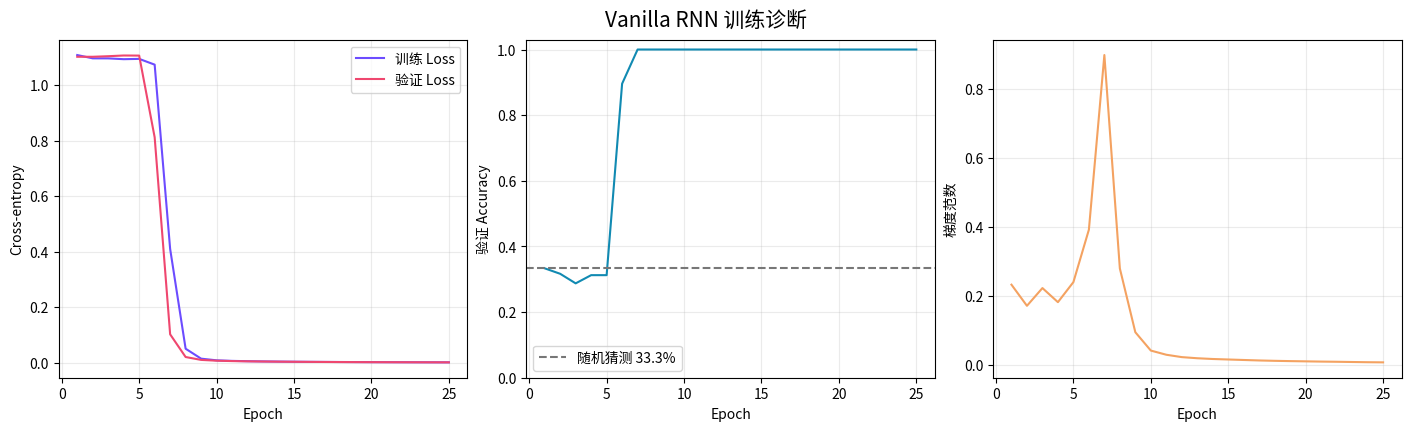

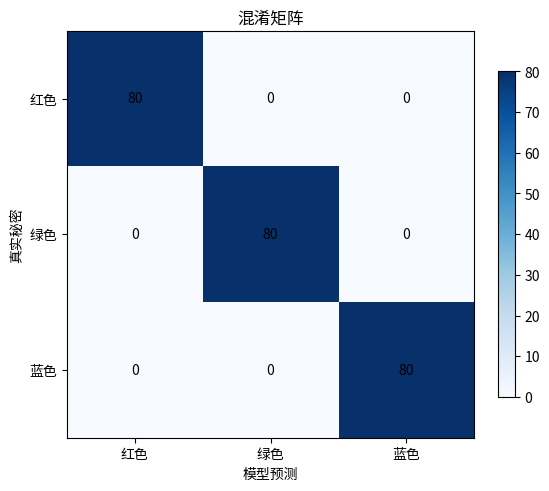

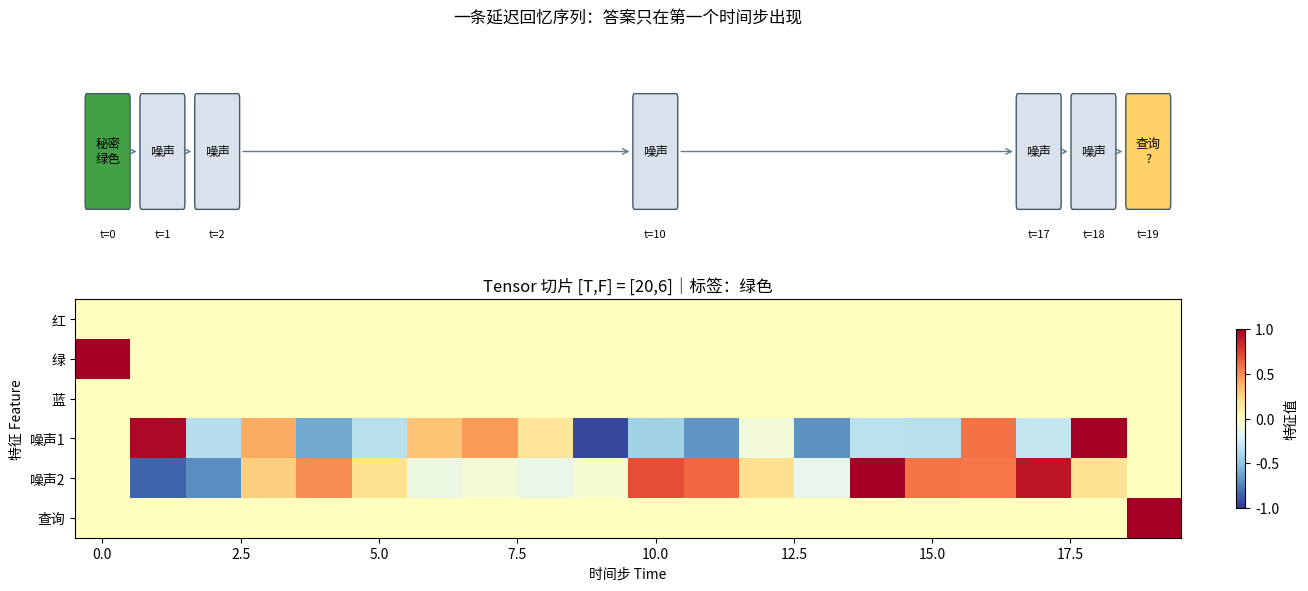

In [3]:
test_x, test_y = next(iter(result["loaders"]["test"]))
plot_training_history(result["history"], title="Vanilla RNN 训练诊断")
plot_confusion_matrix(result["metrics"]["targets"], result["metrics"]["predictions"])
plot_sequence_sample(test_x, test_y, index=1)

probabilities = predict_proba(result["model"], test_x[:5], DEVICE)
for row in range(5):
    print(
        f"样本 {row}｜真实={int(test_y[row])}｜预测={int(probabilities[row].argmax())}｜"
        f"概率={probabilities[row].numpy().round(2).tolist()}"
    )

## 完成一次训练后能够解释什么？

- `CrossEntropyLoss` 比较三类 logits 与真实标签；
- `loss.backward()` 让梯度沿时间反向传播；
- `optimizer.step()` 根据梯度更新参数；
- 验证集用于观察训练过程，测试集只用于最后报告。

Accuracy 高只说明模型在当前合成任务上做对了分类，不等于它理解了颜色或适合所有序列问题。

## 完成本页后：释放资源并结束内核

运行下面最后一个单元格会清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后 VS Code 显示“内核已停止”或要求重新选择内核属于正常现象。再次实验时重新选择课程内核即可。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)